In [2]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from IPython.display import display
from pandas.api.types import CategoricalDtype

from category_encoders import MEstimateEncoder
from category_encoders import CatBoostEncoder

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Set Matplotlib defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Mute warnings
warnings.filterwarnings('ignore')

## Data Preprocessing ##

- **Load** the data from CSV files
- **Clean** the data to fix any errors or inconsistencies
- **Encode** the statistical data type (numeric, categorical)
- **Impute** any missing values

In [3]:
def load_data():
    # Read data
    data_dir = Path("/kaggle/input/datasets/joelzcharia/contraceptive-prevalence-survey/1987 Indonesia Contraception Prevalence Study.csv")
    df = pd.read_csv(data_dir)
    df.columns = df.columns.str.strip()
    return df
    # Preprocessing
    # df = clean(df)
    # df = encode(df)
    # df = impute(df)

In [4]:
# Loading and Inspecting the Data

df = load_data()
print(df.shape, "\n")
print(df.dtypes, "\n")
print(df.head(10), "\n")
print(df.describe(), "\n")
print(df.info(), "\n")



(1473, 10) 

Age                          int64
Education                    int64
Partner Education            int64
Number of Children           int64
Religion = Islam             int64
Currently working            int64
Husband Occupation           int64
Standard of Living           int64
Media Exposure               int64
Contraceptive Method Used    int64
dtype: object 

   Age  Education  Partner Education  Number of Children  Religion = Islam  \
0   24          2                  3                   3                 1   
1   45          1                  3                  10                 1   
2   43          2                  3                   7                 1   
3   42          3                  2                   9                 1   
4   36          3                  3                   8                 1   
5   19          4                  4                   0                 1   
6   38          2                  3                   6                 1 

In [5]:
# Check for Missing Data and Duplicated Data

df.isna().sum()
df.duplicated().sum()
df[df.duplicated()]

,Age,Education,Partner Education,Number of Children,Religion = Islam,Currently working,Husband Occupation,Standard of Living,Media Exposure,Contraceptive Method Used
79,38,4,4,1,1,0,1,4,0,1
167,26,4,4,1,1,1,1,4,0,1
224,47,4,4,4,1,1,1,4,0,1
270,30,4,4,2,1,1,1,4,0,1
299,26,4,4,1,1,1,1,4,0,1
394,29,4,4,0,1,0,2,4,0,1
414,20,2,3,3,1,1,3,4,0,1
462,36,4,4,3,1,1,1,4,0,2
492,37,4,4,3,1,1,1,4,0,2
528,29,4,4,2,1,0,1,3,0,2


In [6]:
# Recode Currently Working and Media Exposure to fix inverted coding
df["Currently working recoded"] = df["Currently working"].map({0:1, 1:0})
df["Media Exposure recoded"] = df["Media Exposure"].map({0:1, 1:0})

# Recode Contraceptive Method for more logical progression - 1 = none, 2 = short term, 3 = long term
df["Contraceptive Method Used recoded"] = df["Contraceptive Method Used"].map({1:1, 2:3, 3:2})
df[["Currently working recoded", "Media Exposure recoded", "Contraceptive Method Used recoded"]].head(10)



,Currently working recoded,Media Exposure recoded,Contraceptive Method Used recoded
0,0,1,1
1,0,1,1
2,0,1,1
3,0,1,1
4,0,1,1
5,0,1,1
6,0,1,1
7,1,1,1
8,0,1,1
9,0,0,1


In [7]:
# Create Age Groups

bins = [15, 19, 24, 29, 34, 39, 44, 49]
lab = ["15–19", "20–24", "25–29", "30–34", "35–39", "40–44", "45–49"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=lab, include_lowest=True)
df["Age Group"].value_counts()

Age Group
25–29    330
30–34    279
35–39    248
20–24    240
40–44    181
45–49    159
15–19     36
Name: count, dtype: int64

In [8]:
# Analyze percentage of women in each age group

age_distribution = (df['Age Group'].value_counts(normalize=True) * 100).round(2)

# pct_dist = df.groupby('Age Group').size()/len(df) * 100

print(age_distribution)

Age Group
25–29    22.40
30–34    18.94
35–39    16.84
20–24    16.29
40–44    12.29
45–49    10.79
15–19     2.44
Name: proportion, dtype: float64


In [9]:
# Analyze percentage of women in each age gourp using each contraceptive method

contra_perc = df.groupby('Age Group')['Contraceptive Method Used recoded'].value_counts(normalize=True).mul(100).round(2)

print(contra_perc)

Age Group  Contraceptive Method Used recoded
15–19      1                                    50.00
           2                                    41.67
           3                                     8.33
20–24      1                                    45.00
           2                                    40.83
           3                                    14.17
25–29      2                                    43.33
           1                                    38.79
           3                                    17.88
30–34      2                                    40.86
           1                                    34.77
           3                                    24.37
35–39      2                                    34.68
           1                                    34.27
           3                                    31.05
40–44      1                                    46.96
           3                                    33.15
           2                         

In [10]:
# Analyze percentage of women using each contraceptive method

contra_dist = df.groupby('Contraceptive Method Used recoded').size()/len(df) * 100

print(contra_dist)

Contraceptive Method Used recoded
1    42.701969
2    34.691107
3    22.606925
dtype: float64


In [11]:
df["Young Mother"] = ((df["Age"] < 25) & (df["Number of Children"] > 0)).astype(int)

df["SES Score"] = (df["Education"] + df["Standard of Living"]) / 2

df["Education Gap"] = df["Education"] - df["Partner Education"]

df["High Parity"] = (df["Number of Children"] >= 4).astype(int)

df["Years Repro"]       = (df["Age"] - 18).clip(lower=1)   # never divide by 0

df["Children Per Year"] = df["Number of Children"] / df["Years Repro"]

df.head(10)

,Age,Education,Partner Education,Number of Children,Religion = Islam,Currently working,Husband Occupation,Standard of Living,Media Exposure,Contraceptive Method Used,Currently working recoded,Media Exposure recoded,Contraceptive Method Used recoded,Age Group,Young Mother,SES Score,Education Gap,High Parity,Years Repro,Children Per Year
0,24,2,3,3,1,1,2,3,0,1,0,1,1,20–24,1,2.5,-1,0,6,0.500000
1,45,1,3,10,1,1,3,4,0,1,0,1,1,45–49,0,2.5,-2,1,27,0.370370
2,43,2,3,7,1,1,3,4,0,1,0,1,1,40–44,0,3.0,-1,1,25,0.280000
3,42,3,2,9,1,1,3,3,0,1,0,1,1,40–44,0,3.0,1,1,24,0.375000
4,36,3,3,8,1,1,3,2,0,1,0,1,1,35–39,0,2.5,0,1,18,0.444444
5,19,4,4,0,1,1,3,3,0,1,0,1,1,15–19,0,3.5,0,0,1,0.000000
6,38,2,3,6,1,1,3,2,0,1,0,1,1,35–39,0,2.0,-1,1,20,0.300000
7,21,3,3,1,1,0,3,2,0,1,1,1,1,20–24,1,2.5,0,0,3,0.333333
8,27,2,3,3,1,1,3,4,0,1,0,1,1,25–29,0,3.0,-1,0,9,0.333333
9,45,1,1,8,1,1,2,2,1,1,0,0,1,45–49,0,1.5,0,1,27,0.296296


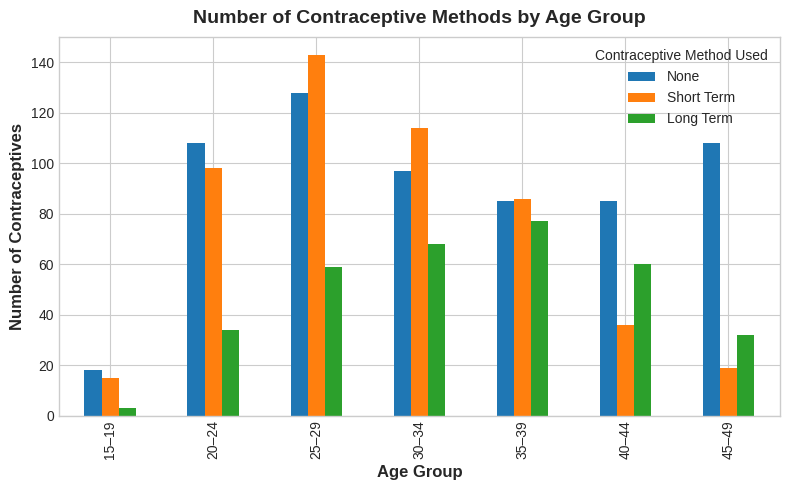

In [12]:
# Create Barchart for Age Distribution 1

counts = df.groupby(['Age Group', 'Contraceptive Method Used recoded']).size().unstack()
counts.plot(kind='bar', stacked=False, figsize=(8,5), title = 'Number of Contraceptive Methods by Age Group' )

plt.xlabel('Age Group')
plt.ylabel('Number of Contraceptives')
plt.legend(title="Contraceptive Method Used", labels=["None", "Short Term", "Long Term"])


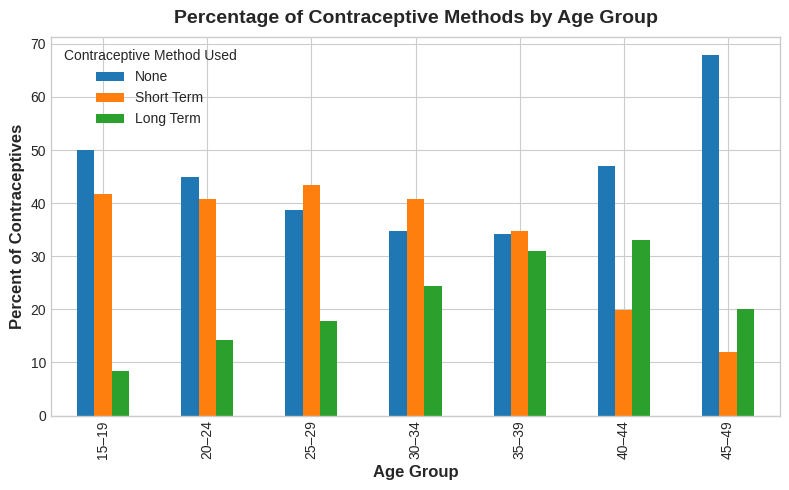

In [13]:
# Create Barchart for Age Distribution 1

per_counts = df.groupby('Age Group')['Contraceptive Method Used recoded'].value_counts(normalize=True).mul(100).unstack()
per_counts.plot(kind='bar', stacked=False, figsize=(8,5), title = 'Percentage of Contraceptive Methods by Age Group' )

plt.xlabel('Age Group')
plt.ylabel('Percent of Contraceptives')
plt.legend(title="Contraceptive Method Used", labels=["None", "Short Term", "Long Term"])


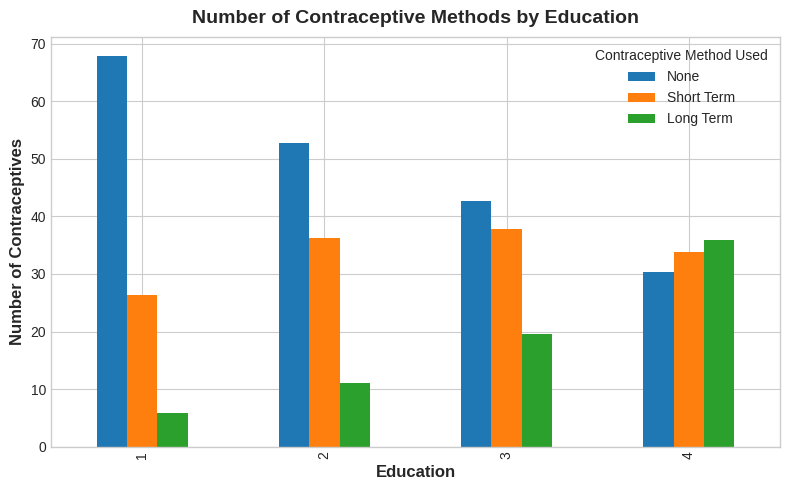

In [14]:
# Barchart 

# counts = df.groupby(['Education', 'Contraceptive Method Used recoded']).size().unstack()
counts = df.groupby('Education')['Contraceptive Method Used recoded'].value_counts(normalize=True).mul(100).unstack()
counts.plot(kind='bar', stacked=False, figsize=(8,5), title = 'Number of Contraceptive Methods by Education' )

plt.xlabel('Education')
plt.ylabel('Number of Contraceptives')
plt.legend(title="Contraceptive Method Used", labels=["None", "Short Term", "Long Term"])


<Axes: title={'center': 'Correlation between Sociodemographic char and Contraceptive Method'}>

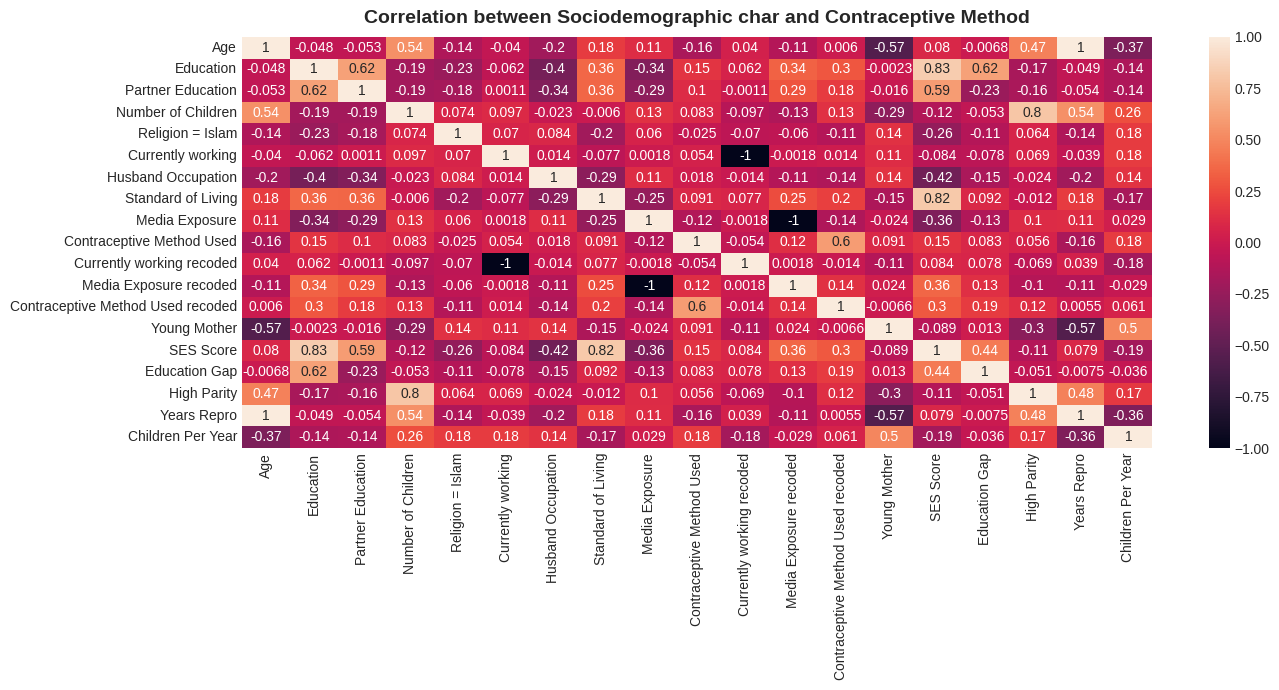

In [15]:
# Heatmap showing Correlation between the sociodemographic variables and contraceptive method used

plt.figure(figsize=(14,7))
plt.title("Correlation between Sociodemographic char and Contraceptive Method")

co_mtx = df.corr(numeric_only=True)
sns.heatmap(co_mtx, annot=True)


### Summary of Findings so far

* We have 1473 participants in this survey
* No duplicates and no missing values
* Lowest age is 16 and highest is 49 with the mean at 32
* The age group with the highest frequency is 25 - 29
* The freq of use of long term contraceptive increases with age group (although drops at 45 - 49)
* The extreme of age groups have the highest frequency of using no contraceptives
* The variables with highest correlation with contraceptive methods are Education, Standard of Living, Partner Education, Media Exposure, Number of children

In [16]:
# Remove old columns

df = df.drop(["Currently working", "Media Exposure", "Contraceptive Method Used"], axis=1)

In [17]:
df.head()

,Age,Education,Partner Education,Number of Children,Religion = Islam,Husband Occupation,Standard of Living,Currently working recoded,Media Exposure recoded,Contraceptive Method Used recoded,Age Group,Young Mother,SES Score,Education Gap,High Parity,Years Repro,Children Per Year
0,24,2,3,3,1,2,3,0,1,1,20–24,1,2.5,-1,0,6,0.500000
1,45,1,3,10,1,3,4,0,1,1,45–49,0,2.5,-2,1,27,0.370370
2,43,2,3,7,1,3,4,0,1,1,40–44,0,3.0,-1,1,25,0.280000
3,42,3,2,9,1,3,3,0,1,1,40–44,0,3.0,1,1,24,0.375000
4,36,3,3,8,1,3,2,0,1,1,35–39,0,2.5,0,1,18,0.444444


In [18]:
# The nominative (unordered) categorical features

# df["Husband Occupation "] = df["Husband Occupation "].astype("category")
# df["Age Group"] = df["Age Group"].astype("object")


In [19]:
base = ["Age", "Education", "Partner Education", "Number of Children",
        "Religion = Islam", "Standard of Living", "Currently working recoded",
        "Media Exposure recoded", "Young Mother", "SES Score", "Education Gap",
        "High Parity", "Children Per Year"]

occ = pd.get_dummies(df["Husband Occupation"], prefix="Occ", drop_first=True).astype(int)

X = pd.concat([df[base], occ], axis=1)
y = df["Contraceptive Method Used recoded"]

FEATURES = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [20]:
# Comparing 3 Models

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# Logistic Regression needs scaling; put it in a Pipeline so scaling
# happens INSIDE each CV fold (prevents data leakage)
logreg = Pipeline([("scaler", StandardScaler()),
                   ("clf", LogisticRegression(max_iter=1000))])
rf  = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                    eval_metric="mlogloss", random_state=42, verbosity=0)
 
for name, model, target in [("LogReg", logreg, y_train),
                            ("RandomForest", rf, y_train),
                            ("XGBoost", xgb, y_train - 1)]:   # XGB: 0-indexed
    s = cross_val_score(model, X_train, target, cv=skf, scoring="f1_macro")
    print(f"{name:14s} F1-macro: {s.mean():.3f} +/- {s.std():.3f}")


LogReg         F1-macro: 0.492 +/- 0.017
RandomForest   F1-macro: 0.501 +/- 0.017
XGBoost        F1-macro: 0.548 +/- 0.025


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

# Shift labels: 1,2,3 → 0,1,2 for XGBoost
xgb.fit(X_train, y_train - 1)
pred = xgb.predict(X_test)

# Shift predictions back: 0,1,2 → 1,2,3 to match your original labels
pred_original = pred + 1

print(classification_report(y_test, pred_original,
      target_names=["None", "Short-term", "Long-term"]))
print(confusion_matrix(y_test, pred_original))

              precision    recall  f1-score   support

        None       0.63      0.60      0.62       126
  Short-term       0.44      0.53      0.48       102
   Long-term       0.42      0.31      0.36        67

    accuracy                           0.51       295
   macro avg       0.49      0.48      0.48       295
weighted avg       0.51      0.51      0.51       295

[[76 40 10]
 [29 54 19]
 [16 30 21]]


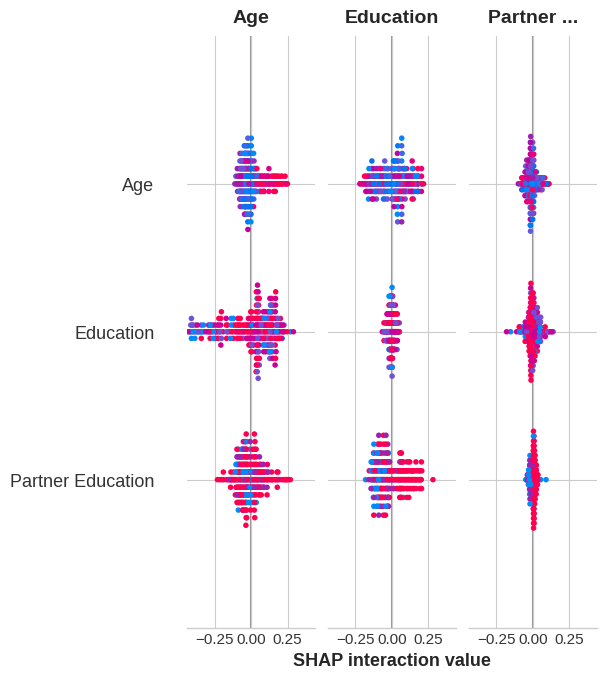

In [27]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
 
# Global view: which features matter most overall
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

In [28]:
joblib.dump(rf, "contraceptive_model.pkl")
joblib.dump(FEATURES, "feature_names.pkl")
print("Saved. Ready for the app.")

Saved. Ready for the app.


In [ ]:
!pip install streamlit shap joblib scikit-learn xgboost


In [ ]:
# train_X = train_X.select_dtypes(exclude=['object'])
# val_X = val_X.select_dtypes(exclude=['object'])

# train_X = pd.get_dummies(train_X)
# val_X = pd.get_dummies(val_X)
# train_X, val_X = train_X.align(val_X, join='left', axis=1)

# train_X

In [ ]:
# Using XGBClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

my_model_2 = XGBClassifier(n_estimators=100, learning_rate=0.05, n_jobs=4)
my_model_2.fit(train_X, train_y, eval_set = [(val_X, val_y)], verbose=False)
predictions_2 = my_model_2.predict(val_X)
# mae = mean_absolute_error(predictions_2, val_y)
print("Accuracy:", accuracy_score(val_y, predictions_2))


# 0.5490401983261108
# 0.5661016949152542
# 0.576271186440678

In [ ]:
from sklearn.feature_selection import mutual_info_classif

def make_mi_scores(X, y):
    discrete_features = X.dtypes == int  # True for integer columns, False for float
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(train_X, train_y)  # only 2 arguments needed now
mi_scores

In [ ]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

In [ ]:
sns.relplot(x="Age", y="Contraceptive Method Used recoded", data=df);

In [ ]:
sns.lmplot(x="Education", y="Contraceptive Method Used recoded", hue="Standard of Living", data=df);


In [ ]:
sns.boxplot(x="Contraceptive Method Used recoded", y="Age", data=df)


In [ ]:
sns.violinplot(x="Contraceptive Method Used recoded", y="Age", data=df)
